# Maximum Likelihood Parameter Learning

## Motivation

In the previous chapters, the parameters of our probabilistic models were assumed to be known.

For example, for a Bernoulli random variable,

$$
X \sim \text{Bernoulli}(\theta),
$$

we assumed that the parameter $\theta$ was already given and used it to compute probabilities or perform inference.

In real applications, however, these parameters are usually unknown and must be estimated from observed data.

Parameter learning reverses the problem:

$$
\boxed{
\text{Model + Observed Data}
\rightarrow
\text{Estimate Model Parameters}
}
$$

For example, if we observe repeated coin tosses but do not know the probability of heads, we can use the observations to estimate it.

The central question is:

> Which parameter values make the observed data most likely?

Maximum Likelihood Estimation (MLE) answers this question by choosing the parameter values that maximize the likelihood of the observed data.

## Parameter Learning

Consider a probabilistic model

$$
P(X \mid \theta),
$$

where:

- $X$ represents the random variable,
- $\theta$ represents the unknown model parameter.

Suppose we observe a dataset

$$
D = \{x_1,x_2,\ldots,x_N\}.
$$

Our goal is to estimate $\theta$ from these observations.

Therefore, parameter learning can be viewed as

$$
D
\rightarrow
\hat{\theta}.
$$

This is different from probabilistic inference.

### Inference

The parameters are known and some variables are unknown:

$$
\theta \text{ known}
\quad\rightarrow\quad
P(X \mid \text{evidence}).
$$

### Parameter Learning

The observations are known and the parameters are unknown:

$$
D \text{ known}
\quad\rightarrow\quad
\hat{\theta}.
$$

## Maximum Likelihood Learning

The general maximum likelihood learning process is:

```text
Observed Data
      ↓
Choose a Probabilistic Model
      ↓
Identify Unknown Parameters
      ↓
Construct the Likelihood
      ↓
L(θ) = P(D | θ)
      ↓
Take the Log-Likelihood
      ↓
ℓ(θ) = log L(θ)
      ↓
Maximize with respect to θ
      ↓
θ̂_MLE


## Likelihood

Suppose we observe

$$
D=\{x_1,x_2,\ldots,x_N\}.
$$

If the observations are independent and identically distributed (i.i.d.), then

$$
P(D\mid\theta)=
\prod_{i=1}^{N}P(x_i\mid\theta).
$$

When the observed data $D$ is fixed and this expression is viewed as a function of the unknown parameter $\theta$, it is called the **likelihood function**:

$$
\boxed{
L(\theta)=
P(D\mid\theta)
}
$$

An important distinction is:

### Probability

Fix the parameter and ask which observations are likely:

$$
P(x\mid\theta).
$$

### Likelihood

Fix the observations and ask which parameter values explain them well:

$$
L(\theta)=P(D\mid\theta).
$$

Therefore,

$$
\boxed{
\text{Probability: parameter fixed, data varies}
}
$$

$$
\boxed{
\text{Likelihood: data fixed, parameter varies}
}
$$

## Bernoulli Maximum Likelihood Estimation

Consider a Bernoulli random variable

$$
X \sim \text{Bernoulli}(\theta),
$$

where

$$
P(X=1)=\theta,
$$

and

$$
P(X=0)=1-\theta.
$$

Suppose we observe

$$
D=\{x_1,x_2,\ldots,x_N\},
$$

with

$$
x_i \in \{0,1\}.
$$

The probability of a single observation is

$$
P(x_i\mid\theta)=
\theta^{x_i}(1-\theta)^{1-x_i}.
$$

Assuming the observations are i.i.d., the likelihood of the complete dataset is

$$
L(\theta)=
\prod_{i=1}^{N}
\theta^{x_i}
(1-\theta)^{1-x_i}.
$$

Let

$$
N_H=\sum_{i=1}^{N}x_i
$$

be the number of heads.

Then the number of tails is

$$
N_T=N-N_H.
$$

Therefore,

$$
L(\theta)=
\theta^{N_H}
(1-\theta)^{N_T}.
$$

### Log-Likelihood

Directly maximizing

$$
L(\theta)=
\theta^{N_H}
(1-\theta)^{N_T}
$$

can be inconvenient because it involves products and powers.

Since the logarithm is monotonically increasing, maximizing the likelihood is equivalent to maximizing the log-likelihood:

$$
\ell(\theta)=
\log L(\theta).
$$

Therefore,

$$
\ell(\theta)=
N_H\log\theta
+
N_T\log(1-\theta).
$$

Differentiate with respect to $\theta$:

$$
\frac{d\ell}{d\theta}=
\frac{N_H}{\theta}-
\frac{N_T}{1-\theta}.
$$

At the maximum,

$$
\frac{d\ell}{d\theta}=0.
$$

Hence,

$$
\frac{N_H}{\theta}=
\frac{N_T}{1-\theta}.
$$

Rearranging,

$$
N_H(1-\theta)=
N_T\theta,
$$

which gives

$$
N_H=
(N_H+N_T)\theta.
$$

Since

$$
N_H+N_T=N,
$$

we obtain

$$
\boxed{
\hat{\theta}_{MLE}=
\frac{N_H}{N}
}
$$

Therefore, the maximum likelihood estimate of the Bernoulli parameter is simply the observed fraction of successful outcomes.

### Algorithm

Given Bernoulli observations

$$
D=\{x_1,\ldots,x_N\},
$$

compute

$$
N_H=\sum_{i=1}^{N}x_i.
$$

Then

$$
\boxed{
\hat{\theta}_{MLE}=
\frac{N_H}{N}
}
$$

The algorithm is therefore:

```text
Input:
    Bernoulli observations x₁, ..., xₙ

Count successful outcomes:
    N_H = Σ xᵢ

Count observations:
    N = number of samples

Estimate:
    θ̂ = N_H / N

Output:
    θ̂


### Load Coin-Toss Dataset

Assuming your dataset looks something like a column containing `0/1` values:

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

coin_data = pd.read_csv(
    "../Datasets/DecisionMakingDatasets/discrete/coin_toss.csv"
)

coin_data.head()

,trial,outcome
0,1,T
1,2,H
2,3,T
3,4,T
4,5,H


#### Inspect the Dataset

In [20]:
coin_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   trial    1000 non-null   int64
 1   outcome  1000 non-null   str  
dtypes: int64(1), str(1)
memory usage: 15.8 KB


In [21]:
coin_data.head(10)

,trial,outcome
0,1,T
1,2,H
2,3,T
3,4,T
4,5,H
5,6,T
6,7,T
7,8,T
8,9,H
9,10,H


In [22]:
samples = coin_data["outcome"].to_numpy()
n_samples = len(samples)
n_heads = np.sum(samples == "H")
n_tails = np.sum(samples == "T")

print(f"Number of tosses: {n_samples}")
print(f"Number of heads:  {n_heads}")
print(f"Number of tails:  {n_tails}")

Number of tosses: 1000
Number of heads:  649
Number of tails:  351


#### Compute the MLE

In [23]:
theta_mle = n_heads / n_samples

print(
    f"Maximum likelihood estimate: "
    f"theta = {theta_mle:.4f}"
)

Maximum likelihood estimate: theta = 0.6490


#### Likelihood Function

In [24]:
def bernoulli_likelihood(
    theta: np.ndarray,
    n_heads: int,
    n_tails: int,
) -> np.ndarray:
    return (
        theta**n_heads
        * (1.0 - theta)**n_tails
    )

#### Evaluate many candidate parameter values

In [25]:
theta_values = np.linspace(
    0.001,
    0.999,
    1000,
)

likelihood_values = bernoulli_likelihood(
    theta_values,
    n_heads,
    n_tails,
)

#### Plot the Likelihood

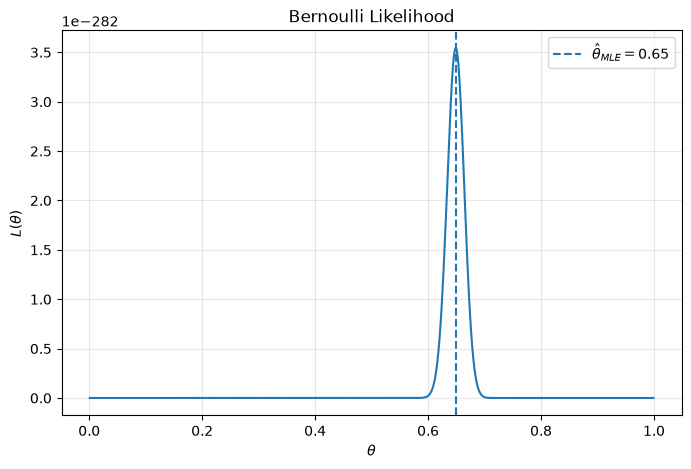

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    theta_values,
    likelihood_values,
)

plt.axvline(
    theta_mle,
    linestyle="--",
    label=rf"$\hat{{\theta}}_{{MLE}}={theta_mle:.2f}$",
)

plt.xlabel(r"$\theta$")
plt.ylabel(r"$L(\theta)$")
plt.title("Bernoulli Likelihood")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Discussion

The likelihood plot shows how well different values of $\theta$ explain the observed coin-toss data.

The observed dataset remains fixed while $\theta$ is varied.

The likelihood reaches its maximum at

$$
\hat{\theta}_{MLE}=
\frac{N_H}{N}.
$$

Therefore, for Bernoulli data, maximum likelihood estimation reduces to the empirical frequency of the successful outcome.

This gives an intuitive interpretation:

$$
\boxed{
\text{MLE probability estimate}=
\text{observed relative frequency}
}
$$

As more data is collected, the empirical frequency generally becomes a more reliable estimate of the underlying probability.

## Categorical Maximum Likelihood Estimation

The Bernoulli distribution represents a random variable with two possible outcomes.

A categorical distribution generalizes this idea to $K$ possible outcomes.

Consider

$$
X \sim \text{Categorical}(\theta_1,\theta_2,\ldots,\theta_K),
$$

where

$$
P(X=k)=\theta_k,
$$

and

$$
\sum_{k=1}^{K}\theta_k=1.
$$

Suppose we observe a dataset

$$
D=\{x_1,x_2,\ldots,x_N\}.
$$

Let $N_k$ denote the number of observations belonging to category $k$.

The likelihood of the observed data can then be written as

$$
L(\theta_1,\ldots,\theta_K)=
\prod_{k=1}^{K}\theta_k^{N_k}.
$$

Taking the logarithm gives

$$
\ell(\theta_1,\ldots,\theta_K)=
\sum_{k=1}^{K}N_k\log\theta_k.
$$

Because the probabilities must satisfy

$$
\sum_{k=1}^{K}\theta_k=1,
$$

maximizing the likelihood gives

$$
\boxed{
\hat{\theta}_k=
\frac{N_k}{N}
}
$$

for every category $k$.

Therefore, the maximum likelihood estimate of each categorical probability is its observed relative frequency.

### Example: Learning the Probabilities of a Die

Consider a six-sided die with unknown probabilities

$$
\theta=
(\theta_1,\theta_2,\theta_3,\theta_4,\theta_5,\theta_6).
$$

If the die is fair, we would expect

$$
\theta_k=\frac{1}{6}.
$$

However, instead of assuming that the die is fair, we estimate its probabilities directly from observed rolls.

For each face,

$$
\hat{\theta}_k=
\frac{\text{number of times face }k\text{ appears}}
{\text{total number of rolls}}.
$$

The resulting vector

$$
\hat{\theta}=
(\hat{\theta}_1,\ldots,\hat{\theta}_6)
$$

is the maximum likelihood estimate of the categorical distribution.

#### Load the Dataset

In [27]:
dice_data = pd.read_csv(
    "../Datasets/DecisionMakingDatasets/discrete/dice_rolls.csv"
)

dice_data.head()

,trial,roll
0,1,4
1,2,1
2,3,1
3,4,5
4,5,4


#### Inspect the Dataset

In [29]:
dice_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   trial   500 non-null    int64
 1   roll    500 non-null    int64
dtypes: int64(2)
memory usage: 7.9 KB


In [30]:
rolls = dice_data["roll"].to_numpy()

n_samples = len(rolls)

print(f"Number of rolls: {n_samples}")

Number of rolls: 500


#### Count Each Outcome

In [31]:
faces, counts = np.unique(
    rolls,
    return_counts=True,
)

print("Faces: ", faces)
print("Counts:", counts)

Faces:  [1 2 3 4 5 6]
Counts: [ 57  64 134 101  90  54]


In [32]:
probabilities_mle = counts / n_samples

for face, probability in zip(
    faces,
    probabilities_mle,
):
    print(
        f"P(X={face}) = {probability:.4f}"
    )

P(X=1) = 0.1140
P(X=2) = 0.1280
P(X=3) = 0.2680
P(X=4) = 0.2020
P(X=5) = 0.1800
P(X=6) = 0.1080


In [33]:
print(
    f"Sum of probabilities: "
    f"{probabilities_mle.sum():.4f}"
)

Sum of probabilities: 1.0000


#### Visualize the Learned Distribution

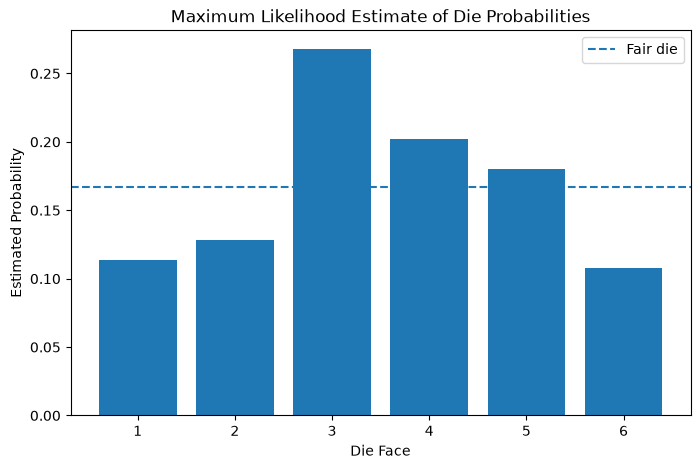

In [34]:
plt.figure(figsize=(8, 5))

plt.bar(
    faces,
    probabilities_mle,
)

plt.axhline(
    1.0 / 6.0,
    linestyle="--",
    label="Fair die",
)

plt.xlabel("Die Face")
plt.ylabel("Estimated Probability")
plt.title("Maximum Likelihood Estimate of Die Probabilities")
plt.legend()

plt.show()

### Discussion

Categorical maximum likelihood estimation follows the same principle as Bernoulli estimation.

For each category,

$$
\boxed{
\hat{\theta}_k=
\frac{N_k}{N}
}
$$

where $N_k$ is the number of times category $k$ appears.

The learned probability vector automatically satisfies

$$
\sum_{k=1}^{K}\hat{\theta}_k=1.
$$

Therefore, for discrete categorical data, maximum likelihood estimation corresponds directly to the empirical distribution of the observations.

Bernoulli estimation is simply the special case where there are only two possible categories.

## Gaussian Maximum Likelihood Estimation

For continuous data, one of the most common probabilistic models is the Gaussian distribution.

Consider a $d$-dimensional random variable

$$
X \sim \mathcal{N}(\mu,\Sigma),
$$

where

- $\mu$ is the mean vector,
- $\Sigma$ is the covariance matrix.

Previously, these parameters were assumed to be known.

In parameter learning, we instead observe samples

$$
D=\{x_1,x_2,\ldots,x_N\}
$$

and estimate

$$
\mu
\quad\text{and}\quad
\Sigma.
$$

The learning problem is therefore

$$
\boxed{
\{x_1,\ldots,x_N\}
\rightarrow
(\hat{\mu},\hat{\Sigma})
}
$$

### Likelihood

For a $d$-dimensional Gaussian,

$$
p(x\mid\mu,\Sigma)=
\frac{1}
{(2\pi)^{d/2}|\Sigma|^{1/2}}
\exp
\left(
-\frac{1}{2}
(x-\mu)^T
\Sigma^{-1}
(x-\mu)
\right).
$$

Assuming the observations are i.i.d., the likelihood of the complete dataset is

$$
L(\mu,\Sigma)=
\prod_{i=1}^{N}
p(x_i\mid\mu,\Sigma).
$$

Instead of maximizing this product directly, we maximize the log-likelihood:

$$
\ell(\mu,\Sigma)=
\sum_{i=1}^{N}
\log p(x_i\mid\mu,\Sigma).
$$

Ignoring terms that do not depend on the parameters,

$$
\ell(\mu,\Sigma)=
-\frac{N}{2}\log|\Sigma|-
\frac{1}{2}
\sum_{i=1}^{N}
(x_i-\mu)^T
\Sigma^{-1}
(x_i-\mu)
+
C.
$$

Maximizing this expression gives the maximum likelihood estimates

$$
\boxed{
\hat{\mu}_{MLE}=
\frac{1}{N}
\sum_{i=1}^{N}x_i
}
$$

and

$$
\boxed{
\hat{\Sigma}_{MLE}=
\frac{1}{N}
\sum_{i=1}^{N}
(x_i-\hat{\mu})
(x_i-\hat{\mu})^T
}
$$

### Algorithm

Given observations

$$
D=\{x_1,\ldots,x_N\},
$$

first estimate the mean:

$$
\hat{\mu}=
\frac{1}{N}
\sum_{i=1}^{N}x_i.
$$

Then estimate the covariance:

$$
\hat{\Sigma}=
\frac{1}{N}
\sum_{i=1}^{N}
(x_i-\hat{\mu})
(x_i-\hat{\mu})^T.
$$

The Gaussian maximum likelihood learning procedure is therefore:

```text
Input:
    Samples x₁, ..., xₙ

Compute sample mean:
    μ̂ = (1/N) Σ xᵢ

Compute deviations:
    dᵢ = xᵢ - μ̂

Compute covariance:
    Σ̂ = (1/N) Σ dᵢ dᵢᵀ

Output:
    μ̂, Σ̂


### Load Gaussian Dataset


In [36]:
gaussian_data = pd.read_csv(
    "../Datasets/DecisionMakingDatasets/continuous/gaussian_samples.csv"
)

gaussian_data.head()

,x1,x2
0,3.305205,1.609971
1,4.224980,2.981426
2,3.850584,2.311841
3,5.793746,2.125202
4,4.748743,1.938277


#### Inspect the Dataset

In [37]:
samples = gaussian_data.to_numpy(dtype=float)

print(f"Number of samples: {samples.shape[0]}")
print(f"Number of dimensions: {samples.shape[1]}")

Number of samples: 1000
Number of dimensions: 2


#### Estimate the Mean

In [38]:
n_samples = samples.shape[0]

mu_mle = np.sum(
    samples,
    axis=0,
) / n_samples

print("Estimated mean:")
print(mu_mle)

Estimated mean:
[4.97345629 2.50335673]


#### Estimate the Covariance

In [39]:
deviations = samples - mu_mle

sigma_mle = (
    deviations.T @ deviations
) / n_samples

print("Estimated covariance:")
print(sigma_mle)

Estimated covariance:
[[1.43445834 0.55775578]
 [0.55775578 0.78549552]]


#### Verify with NumPy

In [40]:
mu_numpy = np.mean(
    samples,
    axis=0,
)

sigma_numpy = np.cov(
    samples,
    rowvar=False,
    bias=True,
)

print(
    "Mean matches:",
    np.allclose(mu_mle, mu_numpy),
)

print(
    "Covariance matches:",
    np.allclose(sigma_mle, sigma_numpy),
)

Mean matches: True
Covariance matches: True


#### Visualizing the Learned Gaussian

The estimated parameters

$$
\hat{\mu}
\quad\text{and}\quad
\hat{\Sigma}
$$

define a new Gaussian distribution

$$
\mathcal{N}(\hat{\mu},\hat{\Sigma}).
$$

If maximum likelihood learning works correctly, this learned distribution should describe the structure of the observed samples.

For two-dimensional data, we can visualize this by plotting the samples together with contours of the learned Gaussian density.

#### Gaussian Density

In [41]:
from scipy.stats import multivariate_normal

x_min, x_max = (
    samples[:, 0].min() - 1.0,
    samples[:, 0].max() + 1.0,
)

y_min, y_max = (
    samples[:, 1].min() - 1.0,
    samples[:, 1].max() + 1.0,
)

x_grid, y_grid = np.meshgrid(
    np.linspace(x_min, x_max, 150),
    np.linspace(y_min, y_max, 150),
)

positions = np.dstack(
    (x_grid, y_grid)
)

learned_gaussian = multivariate_normal(
    mean=mu_mle,
    cov=sigma_mle,
)

density = learned_gaussian.pdf(positions)

#### Plot

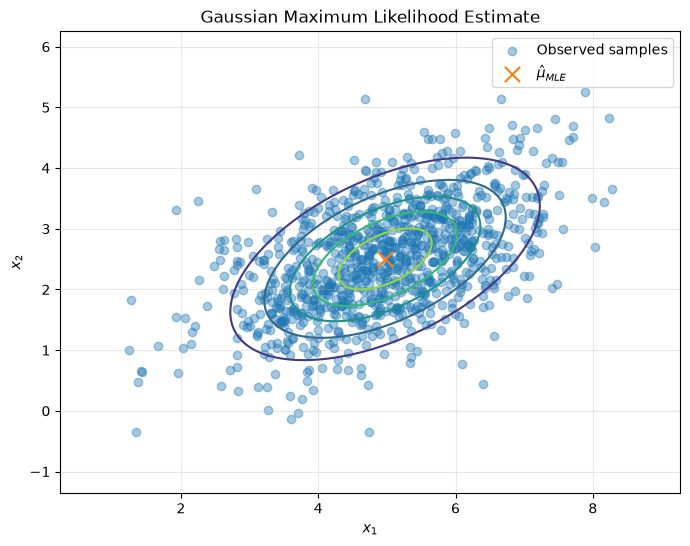

In [42]:
plt.figure(figsize=(8, 6))

plt.scatter(
    samples[:, 0],
    samples[:, 1],
    alpha=0.4,
    label="Observed samples",
)

plt.contour(
    x_grid,
    y_grid,
    density,
    levels=6,
)

plt.scatter(
    mu_mle[0],
    mu_mle[1],
    marker="x",
    s=120,
    label=r"$\hat{\mu}_{MLE}$",
)

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Gaussian Maximum Likelihood Estimate")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Discussion

The estimated mean

$$
\hat{\mu}_{MLE}
$$

describes the center of the observed data.

The estimated covariance

$$
\hat{\Sigma}_{MLE}
$$

describes its spread and correlation structure.

Together they define the Gaussian model

$$
\boxed{
X
\sim
\mathcal{N}
\left(
\hat{\mu}_{MLE},
\hat{\Sigma}_{MLE}
\right)
}
$$

learned directly from observations.

The same principle can now be applied to sensor measurements.

If a sensor measurement is modeled as

$$
z = x + \epsilon,
$$

where

$$
\epsilon \sim \mathcal{N}(0,R),
$$

then observations of the measurement error

$$
e=z-x
$$

can be used to estimate the sensor-noise parameters.

## Robotics Example — Learning Sensor Noise

Robotic systems rarely observe the true state of the world directly.

Instead, sensors provide noisy measurements.

A common measurement model is

$$
z_t = x_t + \epsilon_t,
$$

where

- $x_t$ is the true state,
- $z_t$ is the sensor measurement,
- $\epsilon_t$ is measurement noise.

A common assumption is that the measurement noise follows a Gaussian distribution:

$$
\epsilon_t
\sim
\mathcal{N}(\mu_\epsilon,R).
$$

Often we assume an unbiased sensor,

$$
\mu_\epsilon=0,
$$

but real sensor data may contain systematic bias.

If both ground truth and sensor measurements are available during data collection, the measurement error can be computed as

$$
\epsilon_t=z_t-x_t.
$$

We can then use maximum likelihood estimation to learn

$$
\hat{\mu}_\epsilon
$$

and

$$
\hat{R}.
$$

Therefore,

$$
\boxed{
\text{Ground Truth + Sensor Measurements}
\rightarrow
\text{Measurement Errors}
\rightarrow
\text{MLE}
\rightarrow
(\hat{\mu}_\epsilon,\hat{R})
}
$$

### Load the Robot Dataset

In [43]:
robot_data = pd.read_csv(
    "../Datasets/DecisionMakingDatasets/robotics/robot_sensor_log.csv"
)

robot_data.head()

,time_s,true_x_m,true_y_m,true_velocity_mps,true_heading_rad,gps_x_m,gps_y_m,lidar_x_m,lidar_y_m,velocity_measurement_mps,heading_measurement_rad,gps_error_x_m,gps_error_y_m,lidar_error_x_m,lidar_error_y_m
0,0.0,0.000000,0.000000,1.280000,0.040000,0.389171,-0.116192,-0.186955,0.000243,1.368620,0.057620,0.389171,-0.116192,-0.186955,0.000243
1,0.1,0.127898,0.005119,1.284499,0.041800,-0.127170,0.305739,0.147994,0.067447,1.211959,0.055796,-0.255068,0.300621,0.020097,0.062329
2,0.2,0.256235,0.010486,1.288994,0.043599,0.283851,0.160250,0.495614,0.418710,1.165425,0.037359,0.027616,0.149763,0.239378,0.408224
3,0.3,0.385012,0.016104,1.293484,0.045397,-0.059789,0.137527,0.093869,-0.082504,1.349801,0.062646,-0.444801,0.121423,-0.291144,-0.098608
4,0.4,0.514227,0.021974,1.297968,0.047194,0.915233,0.474460,0.072914,0.398295,1.263833,0.063715,0.401005,0.452486,-0.441314,0.376320


#### Inspect the Dataset

In [44]:
robot_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   time_s                    400 non-null    float64
 1   true_x_m                  400 non-null    float64
 2   true_y_m                  400 non-null    float64
 3   true_velocity_mps         400 non-null    float64
 4   true_heading_rad          400 non-null    float64
 5   gps_x_m                   400 non-null    float64
 6   gps_y_m                   400 non-null    float64
 7   lidar_x_m                 400 non-null    float64
 8   lidar_y_m                 400 non-null    float64
 9   velocity_measurement_mps  400 non-null    float64
 10  heading_measurement_rad   400 non-null    float64
 11  gps_error_x_m             400 non-null    float64
 12  gps_error_y_m             400 non-null    float64
 13  lidar_error_x_m           400 non-null    float64
 14  lidar_error_y_m      

In [47]:
ground_truth = robot_data[
    ["true_x_m", "true_y_m"]
].to_numpy()

gps_measurements = robot_data[
    ["gps_x_m", "gps_y_m"]
].to_numpy()

#### Compute Measurement Errors

In [48]:
gps_errors = (
    gps_measurements
    - ground_truth
)

gps_errors[:5]

array([[ 0.38917139, -0.11619225],
       [-0.25506804,  0.3006206 ],
       [ 0.02761606,  0.14976337],
       [-0.44480088,  0.12142261],
       [ 0.40100515,  0.45248586]])

#### Estimate Sensor Bias

In [49]:
n_samples = len(gps_errors)

gps_bias_mle = (
    np.sum(gps_errors, axis=0)
    / n_samples
)

print("Estimated GPS bias:")
print(gps_bias_mle)

Estimated GPS bias:
[0.01682108 0.01399952]


#### Estimate Sensor Noise Covariance

In [50]:
centered_errors = (
    gps_errors
    - gps_bias_mle
)

gps_covariance_mle = (
    centered_errors.T
    @ centered_errors
) / n_samples

print("Estimated GPS noise covariance:")
print(gps_covariance_mle)

Estimated GPS noise covariance:
[[0.36915091 0.08387361]
 [0.08387361 0.26922325]]


#### Standard Deviation

In [51]:
gps_std = np.sqrt(
    np.diag(gps_covariance_mle)
)

print("GPS standard deviation:")
print(gps_std)

GPS standard deviation:
[0.6075779  0.51886728]


#### Visualize the Measurement Errors

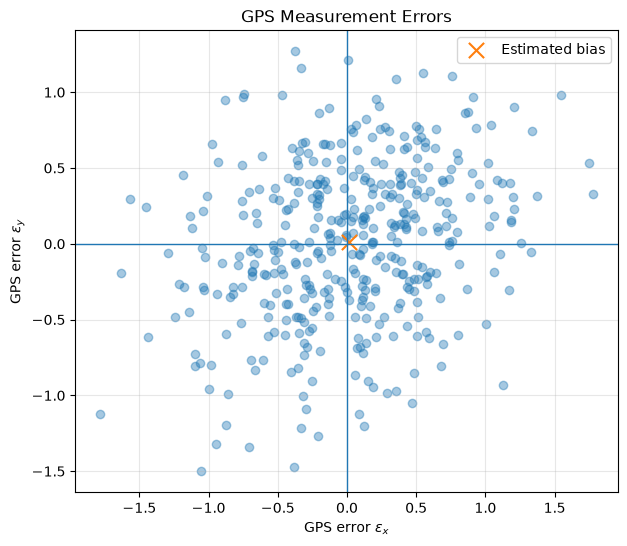

In [52]:
plt.figure(figsize=(7, 6))

plt.scatter(
    gps_errors[:, 0],
    gps_errors[:, 1],
    alpha=0.4,
)

plt.scatter(
    gps_bias_mle[0],
    gps_bias_mle[1],
    marker="x",
    s=120,
    label="Estimated bias",
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel(r"GPS error $\epsilon_x$")
plt.ylabel(r"GPS error $\epsilon_y$")
plt.title("GPS Measurement Errors")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Discussion

The GPS measurement model started as

$$
z_t=x_t+\epsilon_t.
$$

Instead of manually specifying the noise distribution, we used recorded measurements and ground truth to estimate it.

From

$$
\epsilon_t=z_t-x_t,
$$

maximum likelihood estimation gives

$$
\hat{\mu}_\epsilon=
\frac{1}{N}
\sum_t\epsilon_t
$$

and

$$
\hat R=
\frac{1}{N}
\sum_t
(\epsilon_t-\hat{\mu}_\epsilon)
(\epsilon_t-\hat{\mu}_\epsilon)^T.
$$

The learned measurement model is therefore

$$
\boxed{z_t=
x_t+\epsilon_t,
\qquad
\epsilon_t
\sim
\mathcal{N}
(
\hat{\mu}_\epsilon,
\hat R
)
}
$$

This illustrates an important role of parameter learning in robotics:

> The structure of the probabilistic model can be chosen using domain knowledge, while its parameters can be learned from data.

For example, the model may specify that GPS measurements are noisy observations of position, while recorded sensor data determines the actual noise characteristics.